# Customer Segmentation

This notebook performs customer segmentation using the customer-level
behavioural features engineered in the previous stage.

The objective is to identify commercially meaningful groups of customers based
on differences in purchasing engagement, frequency, customer value and product
breadth.

The complete customer feature table is retained for cluster profiling, while a
smaller set of deliberately selected variables is used as clustering input to
avoid giving redundant or highly correlated behavioural dimensions excessive
weight.

Candidate K-Means solutions are evaluated statistically and then interpreted
using the broader customer feature set to select a segmentation that is both
coherent and commercially useful.

In [40]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


REPO_ROOT = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

FIGURES_DIR = REPO_ROOT / "reports" / "figures"
TABLES_DIR = REPO_ROOT / "reports" / "tables"

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True
)


In [41]:
LOCAL_DATA_PATH = (
    REPO_ROOT
    / "data"
    / "processed"
    / "customer_features.parquet"
)

DATA_URL = (
    "https://raw.githubusercontent.com/"
    "apostolis-bloutsos-data/"
    "customer-segmentation-purchase-propensity/"
    "main/data/processed/customer_features.parquet"
)

if LOCAL_DATA_PATH.exists():
    df = pd.read_parquet(LOCAL_DATA_PATH)
    print("Loaded local customer feature dataset.")

else:
    response = requests.get(DATA_URL, timeout=120)
    response.raise_for_status()

    LOCAL_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    LOCAL_DATA_PATH.write_bytes(response.content)

    df = pd.read_parquet(LOCAL_DATA_PATH)
    print("Downloaded customer feature dataset from GitHub.")

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Loaded local customer feature dataset.
Rows: 5,852
Columns: 17


In [42]:
segmentation_feature_columns = [
    "recency_days",
    "frequency",
    "monetary_value",
    "unique_products",
    "average_order_value",
    "tenure_days",
    "cancellation_value_rate"
]

In [43]:
# Segmentation features modeling matrix

X = df[segmentation_feature_columns].copy()

X.head()

,recency_days,frequency,monetary_value,unique_products,average_order_value,tenure_days,cancellation_value_rate
0,326,4,77353.96,26,19338.490,722,0.997798
1,2,8,5633.32,126,704.165,404,0.000000
2,75,5,1658.40,24,331.680,438,0.000000
3,19,3,3678.69,137,1226.230,589,0.006565
4,310,1,294.40,16,294.400,310,0.000000


In [44]:
print(f"Customers: {len(X):,}")
print(f"Features: {X.shape[1]}")

print()
print(X.isna().sum())

Customers: 5,852
Features: 7

recency_days               0
frequency                  0
monetary_value             0
unique_products            0
average_order_value        0
tenure_days                0
cancellation_value_rate    0
dtype: int64


In [45]:
assert len(X) == len(df)
assert X.shape[1] == 7
assert X.notna().all().all()

print("Segmentation input validation passed.")

Segmentation input validation passed.


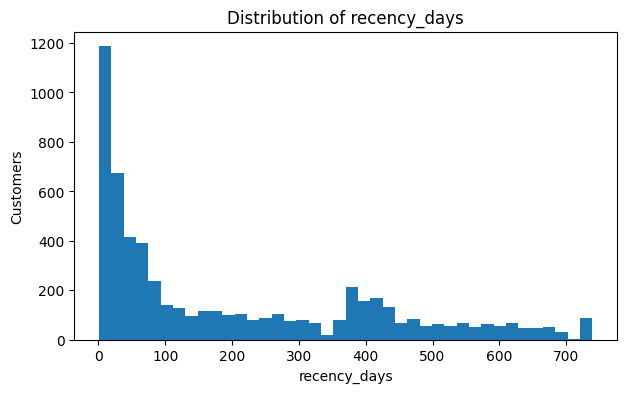

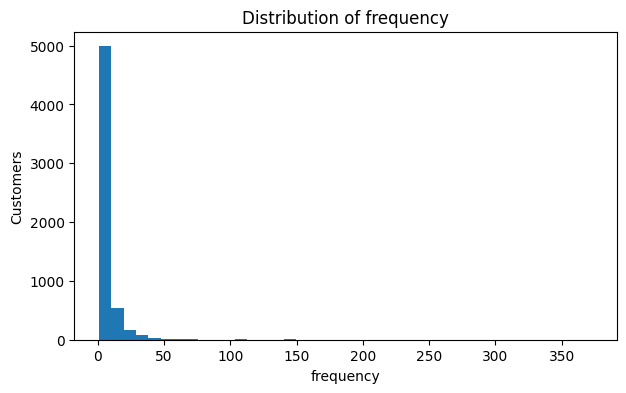

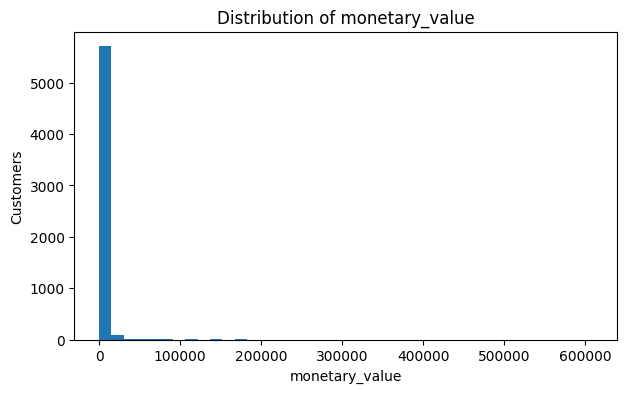

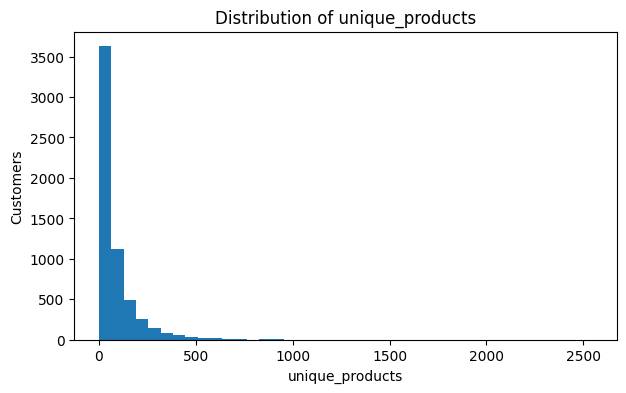

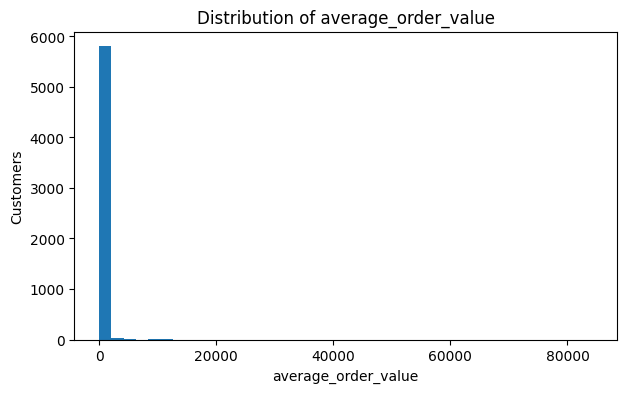

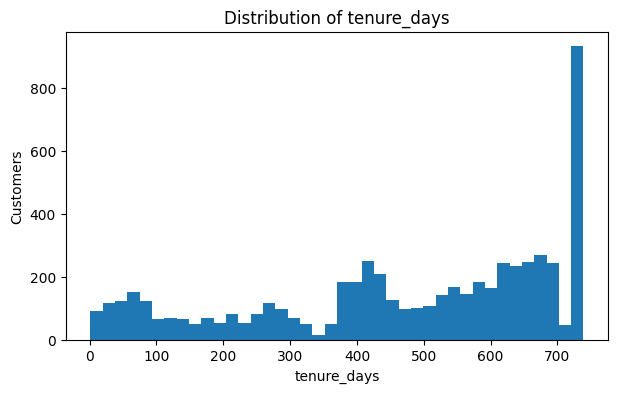

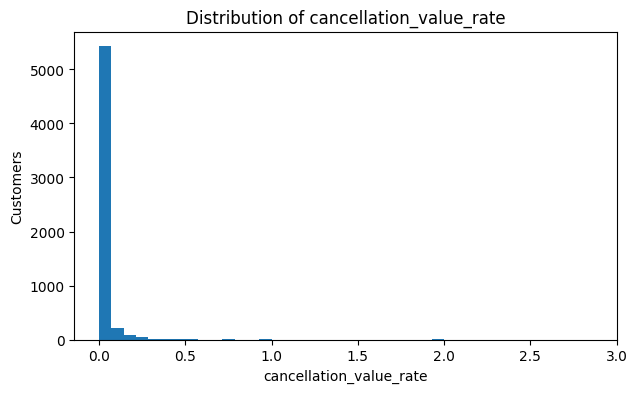

In [46]:
for column in segmentation_feature_columns:
    plt.figure(figsize=(7, 4))
    plt.hist(X[column], bins=40)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Customers")
    plt.show()

### Segmentation feature selection

Visual inspection confirms strong right-skew in frequency, monetary value,
product breadth and average order value. Cancellation value rate is highly
zero-inflated and also contains a long upper tail.

Tenure behaves differently. A substantial concentration occurs near the
maximum observation period because the dataset records only the first purchase
observed within the available data. Customers whose first recorded transaction
occurs near the beginning of the dataset may have had an earlier relationship
with the retailer. Tenure is therefore an observed-history measure rather than
a reliable measure of true customer age.

Average order value is also derived directly from monetary value and frequency.
Including all three in a distance-based clustering model would give purchasing
value/order-size behaviour additional weight.

For these reasons, tenure and average order value are retained for subsequent
cluster profiling but excluded from the initial clustering input.

The clustering model therefore uses five complementary behavioural dimensions:

- recency;
- purchase frequency;
- gross merchandise value;
- product breadth; and
- cancellation value rate.

In [47]:
# Redefine the modelling matrix using the selected segmentation features.

segmentation_feature_columns = [
    "recency_days",
    "frequency",
    "monetary_value",
    "unique_products",
    "cancellation_value_rate"
]

X = df[segmentation_feature_columns].copy()

In [48]:
# # Apply log1p transformation to the selected clustering features.

X_transformed = np.log1p(X)

### Feature transformation

A `log1p` transformation is applied to reduce the strong right-skew of the
clustering variables and limit the disproportionate influence of extreme
customers on distance calculations.

`log1p` is preferred to the ordinary logarithm because it is defined when a
feature equals zero, as occurs frequently for cancellation behaviour.

The objective is not to make every variable normally distributed—K-Means does
not require normality—but to compress extreme ranges while preserving customer
ordering. This is particularly important for variables such as frequency,
monetary value and product breadth, where a small number of customers have
values many times larger than the typical customer.




In [49]:
transformation_comparison = pd.DataFrame({
    "before": X.skew(),
    "after_log1p": X_transformed.skew()
})

transformation_comparison

,before,after_log1p
recency_days,0.894319,-0.485909
frequency,12.040277,1.001951
monetary_value,25.583767,0.265863
unique_products,6.220775,-0.257935
cancellation_value_rate,12.320906,8.103414


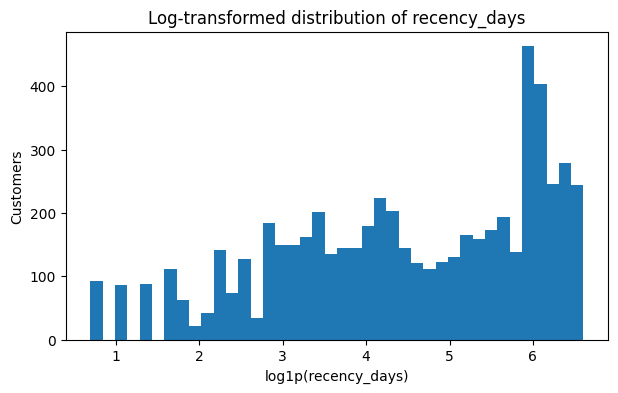

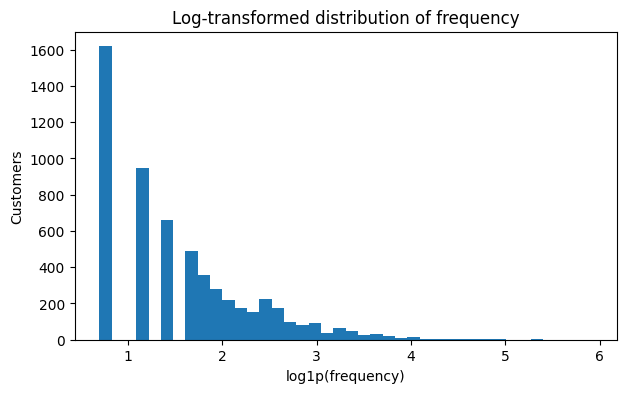

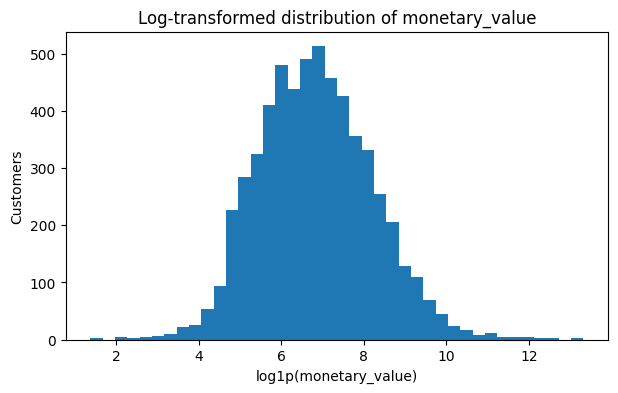

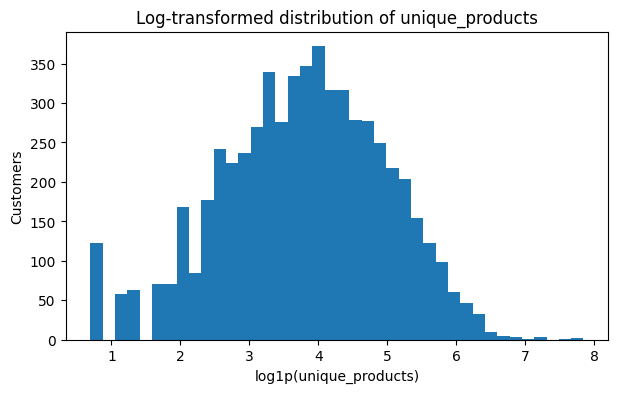

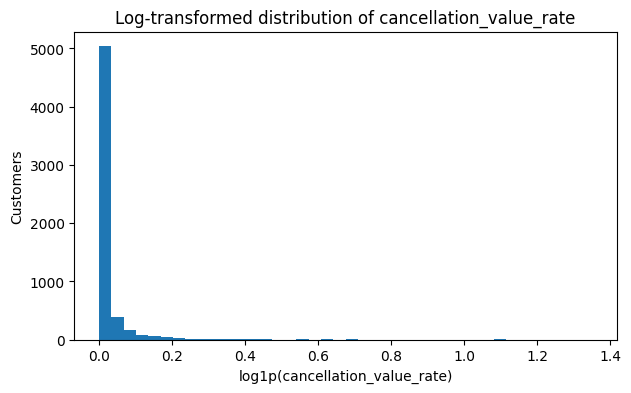

In [50]:
for column in segmentation_feature_columns:
    plt.figure(figsize=(7, 4))
    plt.hist(X_transformed[column], bins=40)
    plt.title(f"Log-transformed distribution of {column}")
    plt.xlabel(f"log1p({column})")
    plt.ylabel("Customers")
    plt.show()

In [51]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_transformed)

In [52]:
X_scaled = pd.DataFrame(
    X_scaled,
    columns=segmentation_feature_columns,
    index=df.index
)

X_scaled.head()

,recency_days,frequency,monetary_value,unique_products,cancellation_value_rate
0,0.860933,0.077074,3.201676,-0.391828,9.533911
1,-2.150170,0.804820,1.307765,0.890339,-0.299139
2,-0.075659,0.302808,0.423959,-0.455558,-0.299139
3,-0.932519,-0.199203,0.999734,0.959126,-0.206166
4,0.828734,-1.057398,-0.823848,-0.774920,-0.299139


In [53]:
assert X_scaled.shape == (
    len(df),
    5
)
assert np.isfinite(
    X_scaled.to_numpy()
).all()

print("Clustering feature preparation passed.")

Clustering feature preparation passed.


In [54]:
X_scaled.describe().T[
    ["mean", "std", "min", "max"]
]

,mean,std,min,max
recency_days,-4.043246e-16,1.000085,-2.410415,1.385119
frequency,1.748431e-16,1.000085,-1.057398,5.419308
monetary_value,6.410912e-16,1.000085,-3.943301,4.693307
unique_products,-1.153478e-17,1.000085,-2.547079,3.373343
cancellation_value_rate,-2.428376e-18,1.000085,-0.299139,18.886112


### Final clustering feature set

The logarithmic transformation substantially reduced skewness in recency,
frequency, monetary value and product breadth.

Cancellation value rate behaved differently. Most customers have little or no
recorded cancellation value, while a very small number have exceptionally high
ratios. Even after logarithmic transformation and standardization, this feature
retains extreme standardized values and could disproportionately influence
Euclidean distances in K-Means.

Rather than applying additional arbitrary clipping or outlier treatment,
cancellation behaviour is excluded from the clustering input and retained for
post-clustering business profiling.

The final clustering feature set therefore consists of:

- `recency_days`
- `frequency`
- `monetary_value`
- `unique_products`

Cancellation metrics, average order value, tenure and the remaining engineered
features remain available for interpreting and profiling the resulting customer
segments.

In [55]:
segmentation_feature_columns = [
    "recency_days",
    "frequency",
    "monetary_value",
    "unique_products"
]

X = df[segmentation_feature_columns].copy()

X_transformed = np.log1p(X)

scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X_transformed),
    columns=segmentation_feature_columns,
    index=df.index
)

In [56]:
assert X_scaled.shape == (
    len(df),
    4
)
assert np.isfinite(
    X_scaled.to_numpy()
).all()

print("Final clustering feature preparation passed.")

Final clustering feature preparation passed.


In [57]:
X_scaled.describe().T[
    ["mean", "std", "min", "max"]
]

,mean,std,min,max
recency_days,-4.043246e-16,1.000085,-2.410415,1.385119
frequency,1.748431e-16,1.000085,-1.057398,5.419308
monetary_value,6.410912e-16,1.000085,-3.943301,4.693307
unique_products,-1.153478e-17,1.000085,-2.547079,3.373343


## Selecting the number of clusters

The number of customer segments is not chosen randomly.

Candidate K-Means solutions are evaluated from `k = 2` to `k = 10` using:

- **Inertia**, which measures within-cluster dispersion and is used to track how far apart data points are from their center;
- **Silhouette score**, which evaluates how well customers fit within their
  assigned cluster relative to neighbouring clusters; and
- **Cluster-size balance**, to avoid selecting a statistically attractive
  solution that produces extremely small or commercially impractical segments.

The final value of `k` will therefore consider both statistical structure and
business interpretability.

In [58]:
k_values = range(2, 11)

inertias = []
silhouette_scores = []
cluster_sizes = {}

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

    cluster_sizes[k] = pd.Series(labels).value_counts().sort_index()

In [59]:
k_evaluation = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": silhouette_scores
})

k_evaluation.to_csv(
    TABLES_DIR / "kmeans_candidate_evaluation.csv",
    index=False
)

k_evaluation

,k,inertia,silhouette_score
0,2,11943.682180,0.408806
1,3,9067.033685,0.312314
2,4,7594.561573,0.310597
3,5,6584.136069,0.272031
4,6,5906.210336,0.256314
5,7,5328.526921,0.258053
6,8,4956.399292,0.245583
7,9,4662.957589,0.252031
8,10,4387.003182,0.242151


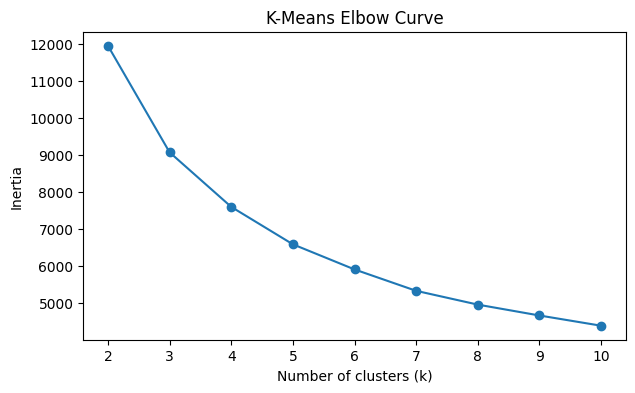

In [60]:
plt.figure(figsize=(7, 4))
plt.plot(
    k_evaluation["k"],
    k_evaluation["inertia"],
    marker="o"
)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Curve")
plt.xticks(list(k_values))

plt.savefig(
    FIGURES_DIR / "kmeans_inertia_by_k.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

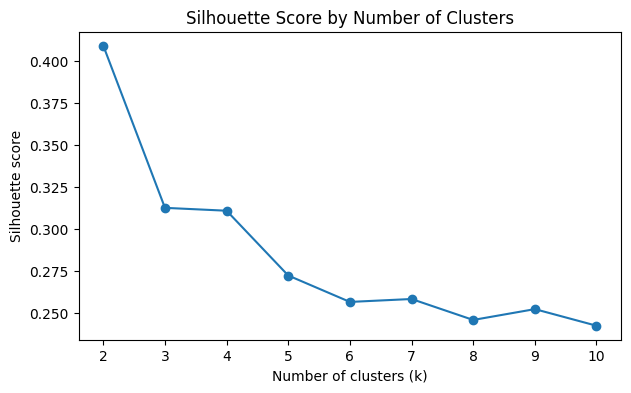

In [61]:
plt.figure(figsize=(7, 4))
plt.plot(
    k_evaluation["k"],
    k_evaluation["silhouette_score"],
    marker="o"
)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette Score by Number of Clusters")
plt.xticks(list(k_values))

plt.savefig(
    FIGURES_DIR / "kmeans_silhouette_by_k.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [62]:
for k in k_values:
    sizes = cluster_sizes[k]

    print(f"\nk = {k}")
    print(sizes.to_string())
    print(
        f"Smallest cluster: {sizes.min():,} "
        f"({sizes.min() / len(X_scaled) * 100:.2f}%)"
    )


k = 2
0    2457
1    3395
Smallest cluster: 2,457 (41.99%)

k = 3
0    2169
1    2393
2    1290
Smallest cluster: 1,290 (22.04%)

k = 4
0    1529
1    1209
2    1252
3    1862
Smallest cluster: 1,209 (20.66%)

k = 5
0    1137
1    1180
2    1437
3     670
4    1428
Smallest cluster: 670 (11.45%)

k = 6
0    1419
1    1085
2     787
3    1055
4    1075
5     431
Smallest cluster: 431 (7.37%)

k = 7
0     719
1     452
2     625
3     787
4     884
5    1173
6    1212
Smallest cluster: 452 (7.72%)

k = 8
0     551
1     794
2     278
3    1089
4     760
5     663
6    1096
7     621
Smallest cluster: 278 (4.75%)

k = 9
0     277
1     566
2     786
3    1058
4    1016
5     202
6     734
7     533
8     680
Smallest cluster: 202 (3.45%)

k = 10
0    977
1    274
2    696
3    753
4    510
5    474
6    528
7    188
8    531
9    921
Smallest cluster: 188 (3.21%)


In [63]:
cluster_balance = []

for k in k_values:
    sizes = cluster_sizes[k]

    cluster_balance.append({
        "k": k,
        "smallest_cluster": sizes.min(),
        "smallest_cluster_pct": (
            sizes.min() / len(X_scaled) * 100
        ),
        "largest_cluster": sizes.max(),
        "largest_cluster_pct": (
            sizes.max() / len(X_scaled) * 100
        )
    })

cluster_balance = pd.DataFrame(cluster_balance)

cluster_balance

,k,smallest_cluster,smallest_cluster_pct,largest_cluster,largest_cluster_pct
0,2,2457,41.985646,3395,58.014354
1,3,1290,22.043746,2393,40.892003
2,4,1209,20.659604,1862,31.818182
3,5,670,11.449077,1437,24.555707
4,6,431,7.365003,1419,24.248120
5,7,452,7.723855,1212,20.710868
6,8,278,4.750513,1096,18.728640
7,9,202,3.451811,1058,18.079289
8,10,188,3.212577,977,16.695147


### Candidate cluster solutions

The two-cluster solution produces the highest silhouette score, indicating a
strong broad separation in the customer base. However, two segments may be too
coarse for the project's customer-segmentation objective.

The three- and four-cluster solutions provide nearly identical silhouette
scores (approximately 0.312 and 0.311 respectively), while the four-cluster
solution reduces within-cluster inertia further and maintains particularly
balanced segment sizes: its smallest cluster contains approximately 21% of
customers and its largest approximately 32%.

Moving beyond four clusters produces progressively lower silhouette scores and
smaller customer groups without an equally clear improvement in separation.

Therefore, three- and four-cluster solutions are retained as the principal
candidates. The final value of `k` will be selected by comparing their
customer profiles and determining whether the additional fourth segment
represents distinct and commercially meaningful behaviour rather than a
random subdivision.

In [64]:
candidate_models = {}

for k in [3, 4]:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_scaled)

    candidate_models[k] = {
        "model": model,
        "labels": labels
    }

In [65]:
# Profile cluster behaviour using the complete customer feature table.

def profile_clusters(data, labels):
    profiled = data.copy()
    profiled["cluster"] = labels

    profile = (
        profiled
        .groupby("cluster")
        .agg(
            customers=("customer_id", "size"),

            recency_days=("recency_days", "median"),
            frequency=("frequency", "median"),
            monetary_value=("monetary_value", "median"),
            unique_products=("unique_products", "median"),

            average_order_value=("average_order_value", "median"),
            tenure_days=("tenure_days", "median"),

            cancellation_rate=("cancellation_rate", "median"),
            cancellation_value_rate=("cancellation_value_rate", "median"),
            net_merchandise_value=("net_merchandise_value", "median")
        )
    )

    profile["customer_pct"] = (
        profile["customers"] / len(profiled) * 100
    )

    return profile

In [66]:
profile_k3 = profile_clusters(
    df,
    candidate_models[3]["labels"]
)

profile_k4 = profile_clusters(
    df,
    candidate_models[4]["labels"]
)

print("k = 3")
display(profile_k3.round(2))

print("k = 4")
display(profile_k4.round(2))

k = 3


,customers,recency_days,frequency,monetary_value,unique_products,average_order_value,tenure_days,cancellation_rate,cancellation_value_rate,net_merchandise_value,customer_pct
cluster,,,,,,,,,,,
0,2169,387.0,1.0,272.22,15.0,196.89,430.0,0.00,0.00,262.64,37.06
1,2393,75.0,4.0,1106.73,57.0,304.71,514.0,0.00,0.00,1083.71,40.89
2,1290,17.0,12.0,4713.76,172.0,372.78,675.0,0.16,0.01,4635.74,22.04


k = 4


,customers,recency_days,frequency,monetary_value,unique_products,average_order_value,tenure_days,cancellation_rate,cancellation_value_rate,net_merchandise_value,customer_pct
cluster,,,,,,,,,,,
0,1529,234.0,4.0,1215.95,61.0,327.00,598.0,0.00,0.00,1185.46,26.13
1,1209,23.0,3.0,822.57,44.0,263.26,283.0,0.00,0.00,806.57,20.66
2,1252,19.0,12.5,4821.04,175.0,375.81,675.0,0.17,0.01,4711.02,21.39
3,1862,393.0,1.0,243.10,14.0,188.58,431.0,0.00,0.00,237.83,31.82


In [67]:
# Summarize customer and monetary concentration for each candidate solution.

def cluster_business_summary(data, labels):
    profiled = data.copy()
    profiled["cluster"] = labels

    summary = (
        profiled
        .groupby("cluster")
        .agg(
            customers=("customer_id", "size"),
            total_monetary_value=("monetary_value", "sum"),
            mean_monetary_value=("monetary_value", "mean"),
            total_net_value=("net_merchandise_value", "sum")
        )
    )

    summary["customer_pct"] = (
        summary["customers"] / len(profiled) * 100
    )

    summary["revenue_pct"] = (
        summary["total_monetary_value"]
        / summary["total_monetary_value"].sum()
        * 100
    )

    return summary

In [68]:
print("k = 3 business summary")
display(
    cluster_business_summary(
        df,
        candidate_models[3]["labels"]
    ).round(2)
)

print("k = 4 business summary")
display(
    cluster_business_summary(
        df,
        candidate_models[4]["labels"]
    ).round(2)
)

k = 3 business summary


,customers,total_monetary_value,mean_monetary_value,total_net_value,customer_pct,revenue_pct
cluster,,,,,,
0,2169,740850.84,341.56,712774.38,37.06,4.25
1,2393,3584047.60,1497.72,3385948.94,40.89,20.56
2,1290,13108367.31,10161.53,12616275.23,22.04,75.19


k = 4 business summary


,customers,total_monetary_value,mean_monetary_value,total_net_value,customer_pct,revenue_pct
cluster,,,,,,
0,1529,2636288.40,1724.19,2452077.87,26.13,15.12
1,1209,1385729.26,1146.18,1194182.13,20.66,7.95
2,1252,12850894.09,10264.29,12528740.94,21.39,73.71
3,1862,560354.00,300.94,539997.61,31.82,3.21


### Final number of clusters

The three- and four-cluster solutions produced almost identical silhouette
scores, so the final selection was based on whether the additional segment
created meaningful behavioural differentiation.

The four-cluster solution separates the broad middle customer group found in
the three-cluster solution into two distinct lifecycle states.

One group consists of relatively recent customers with moderate purchasing
history and shorter observed tenure. These customers appear to be developing
their relationship with the retailer.

The other consists of longer-tenured customers with similar or greater
historical purchasing activity but substantially poorer recency. These
customers appear established but increasingly inactive and therefore represent
a different retention or reactivation opportunity.

The four-cluster solution also retains balanced segment sizes, with no segment
containing fewer than approximately 20% of customers.

For these reasons, `k = 4` is selected as the final segmentation solution.

The four behavioural segments are provisionally interpreted as:

- **Established At-Risk** — established customers with meaningful historical
  purchasing activity but relatively poor recent engagement;
- **Recent Developing** — recently active customers whose frequency and value
  have not yet reached the strongest customer levels;
- **High-Value Loyal** — highly active, broad-purchasing and economically
  valuable customers;
- **Dormant Low-Value** — infrequent, low-value customers with long periods
  since their most recent purchase.

In [69]:
final_k = 4

final_kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=20
)

df["cluster"] = final_kmeans.fit_predict(X_scaled)

In [70]:
# Map the fitted cluster IDs to interpretable business segment names.

segment_names = {
    0: "Established At-Risk",
    1: "Recent Developing",
    2: "High-Value Loyal",
    3: "Dormant Low-Value"
}

df["segment"] = df["cluster"].map(segment_names)

In [71]:
df["segment"].value_counts()

,count
segment,
Dormant Low-Value,1862
Established At-Risk,1529
High-Value Loyal,1252
Recent Developing,1209


In [72]:
segment_cancellation_profile = (
    df.groupby("segment")
      .agg(
          customers=("customer_id", "size"),
          customers_with_cancellation=(
              "cancellation_count",
              lambda x: (x > 0).sum()
          ),
          mean_cancellation_value_rate=(
              "cancellation_value_rate",
              "mean"
          )
      )
)

segment_cancellation_profile["customers_with_cancellation_pct"] = (
    segment_cancellation_profile["customers_with_cancellation"]
    / segment_cancellation_profile["customers"]
    * 100
)

segment_cancellation_profile.round(2)

,customers,customers_with_cancellation,mean_cancellation_value_rate,customers_with_cancellation_pct
segment,,,,
Dormant Low-Value,1862,297,0.03,15.95
Established At-Risk,1529,719,0.02,47.02
High-Value Loyal,1252,996,0.02,79.55
Recent Developing,1209,410,0.02,33.91


### Cancellation behaviour across segments

Cancellation incidence varies substantially across the four segments. Nearly
80% of High-Value Loyal customers have at least one identifiable cancellation,
compared with approximately 16% of Dormant Low-Value customers.

This difference should not be interpreted as evidence that high-value customers
have disproportionately poor return behaviour. Customers in the High-Value
Loyal segment purchase much more frequently and therefore have substantially
more opportunities to generate at least one cancellation.

When cancellation value is evaluated relative to gross merchandise purchase
value, the average cancellation value rate remains approximately 2% across the
three more active segments and about 3% among Dormant Low-Value customers.

Cancellation incidence therefore appears largely associated with transaction
exposure rather than defining a separate customer-quality dimension. This
supports the decision to retain cancellation measures for business profiling
while excluding them from the variables used to determine the clusters.

In [73]:
final_segment_profile = (
    df.groupby("segment")
      .agg(
          customers=("customer_id", "size"),
          median_recency_days=("recency_days", "median"),
          median_frequency=("frequency", "median"),
          median_monetary_value=("monetary_value", "median"),
          median_unique_products=("unique_products", "median"),
          median_average_order_value=("average_order_value", "median"),
          median_tenure_days=("tenure_days", "median"),
          total_monetary_value=("monetary_value", "sum"),
          mean_cancellation_value_rate=(
              "cancellation_value_rate", "mean"
          ),
          customers_with_cancellation=(
              "cancellation_count",
              lambda x: (x > 0).sum()
          )
      )
)

final_segment_profile["customer_pct"] = (
    final_segment_profile["customers"]
    / len(df)
    * 100
)

final_segment_profile["revenue_pct"] = (
    final_segment_profile["total_monetary_value"]
    / final_segment_profile["total_monetary_value"].sum()
    * 100
)

final_segment_profile["customers_with_cancellation_pct"] = (
    final_segment_profile["customers_with_cancellation"]
    / final_segment_profile["customers"]
    * 100
)

final_segment_profile.index.name = "segment"

final_segment_profile.reset_index().to_csv(
    TABLES_DIR / "segment_business_summary.csv",
    index=False
)

final_segment_profile.round(2)

,customers,median_recency_days,median_frequency,median_monetary_value,median_unique_products,median_average_order_value,median_tenure_days,total_monetary_value,mean_cancellation_value_rate,customers_with_cancellation,customer_pct,revenue_pct,customers_with_cancellation_pct
segment,,,,,,,,,,,,,
Dormant Low-Value,1862,393.0,1.0,243.10,14.0,188.58,431.0,560354.00,0.03,297,31.82,3.21,15.95
Established At-Risk,1529,234.0,4.0,1215.95,61.0,327.00,598.0,2636288.40,0.02,719,26.13,15.12,47.02
High-Value Loyal,1252,19.0,12.5,4821.04,175.0,375.81,675.0,12850894.09,0.02,996,21.39,73.71,79.55
Recent Developing,1209,23.0,3.0,822.57,44.0,263.26,283.0,1385729.26,0.02,410,20.66,7.95,33.91


In [74]:
CUSTOMER_SEGMENTS_PATH = (
    REPO_ROOT
    / "data"
    / "processed"
    / "customer_segments.parquet"
)

CUSTOMER_SEGMENTS_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

df.to_parquet(
    CUSTOMER_SEGMENTS_PATH,
    index=False
)

print(
    f"Saved to: "
    f"{CUSTOMER_SEGMENTS_PATH}"
)

Saved to: /content/data/processed/customer_segments.parquet


In [75]:
test_segments = pd.read_parquet(
    CUSTOMER_SEGMENTS_PATH
)

assert len(test_segments) == len(df)
assert list(test_segments.columns) == list(df.columns)
assert test_segments["segment"].notna().all()

print(
    "Customer segment Parquet round-trip validation passed."
)

Customer segment Parquet round-trip validation passed.


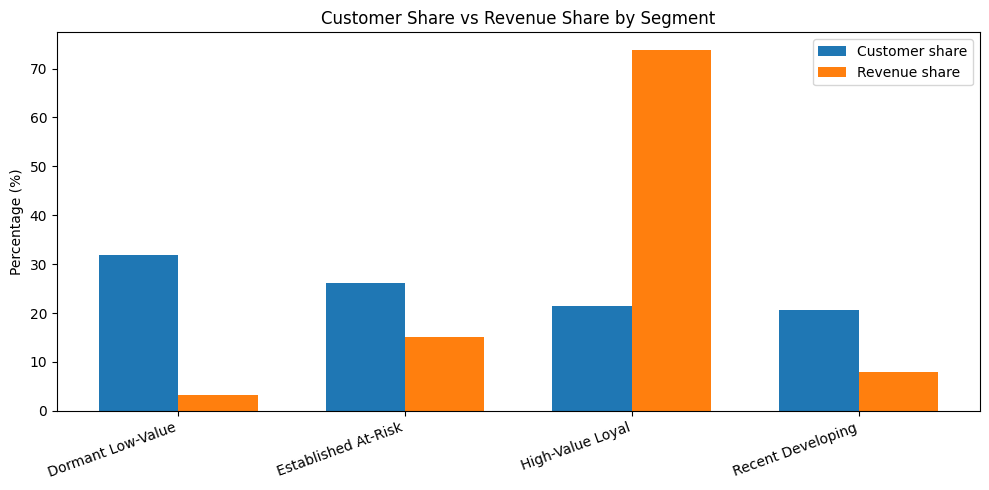

In [76]:
segment_plot = final_segment_profile.reset_index()

x = np.arange(len(segment_plot))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width / 2,
    segment_plot["customer_pct"],
    width,
    label="Customer share"
)

plt.bar(
    x + width / 2,
    segment_plot["revenue_pct"],
    width,
    label="Revenue share"
)

plt.xticks(
    x,
    segment_plot["segment"],
    rotation=20,
    ha="right"
)

plt.ylabel("Percentage (%)")
plt.title("Customer Share vs Revenue Share by Segment")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "segment_customer_vs_revenue_share.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [77]:
profile_metrics = [
    "median_recency_days",
    "median_frequency",
    "median_monetary_value",
    "median_unique_products"
]

profile_for_plot = (
    final_segment_profile[profile_metrics]
    .copy()
)

normalized_profile = (
    profile_for_plot
    / profile_for_plot.max(axis=0)
)

normalized_profile

,median_recency_days,median_frequency,median_monetary_value,median_unique_products
segment,,,,
Dormant Low-Value,1.000000,0.08,0.050424,0.080000
Established At-Risk,0.595420,0.32,0.252218,0.348571
High-Value Loyal,0.048346,1.00,1.000000,1.000000
Recent Developing,0.058524,0.24,0.170621,0.251429


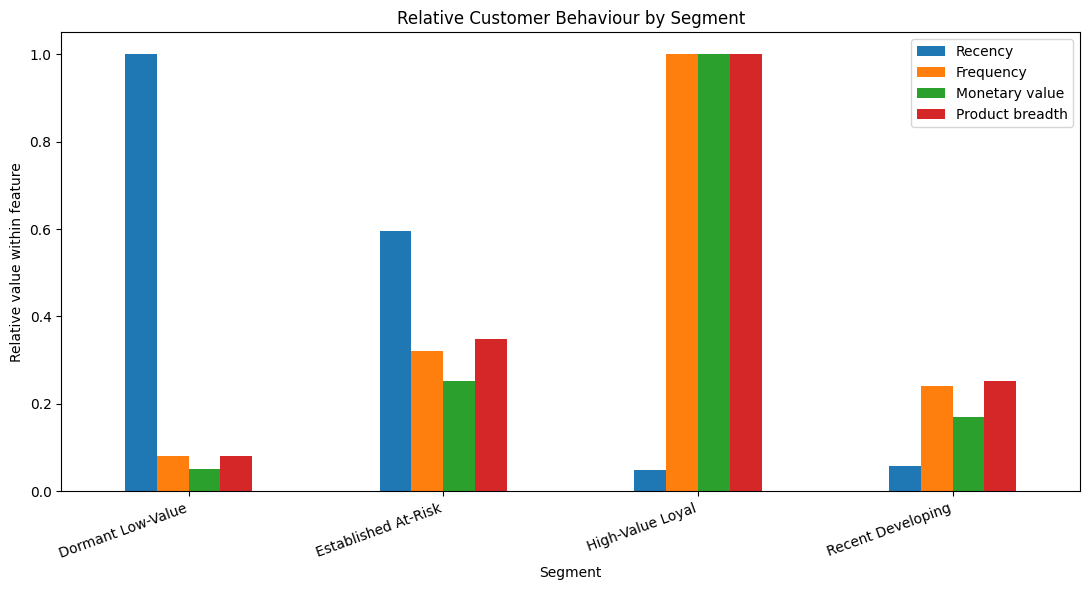

In [78]:
normalized_profile.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.ylabel("Relative value within feature")
plt.xlabel("Segment")
plt.title("Relative Customer Behaviour by Segment")
plt.xticks(rotation=20, ha="right")
plt.legend(
    [
        "Recency",
        "Frequency",
        "Monetary value",
        "Product breadth"
    ]
)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "segment_relative_behavior.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business interpretation and recommended actions

The final four-cluster solution identifies customer groups with substantially
different levels of engagement, economic value and relationship development.

### High-Value Loyal

High-Value Loyal customers represent approximately **21% of customers but
generate almost 74% of total merchandise purchase value**. They purchase very
recently, order frequently, buy across a broad range of products and have the
highest median customer value.

This segment should be treated primarily as a retention and relationship-protection priority. Appropriate actions may include loyalty benefits,
personalised recommendations, early access to products and proactive service.
Because such a large proportion of revenue is concentrated in this relatively
small group, deterioration in their engagement would represent a serious
commercial risk.

### Established At-Risk

Established At-Risk customers account for approximately **26% of customers and
15% of merchandise revenue**. They have relatively long observed relationships
and meaningful historical purchasing activity, but their median recency of
234 days indicates substantial decline in recent engagement.

This segment represents the clearest win-back opportunity. Reactivation
campaigns can prioritise customers with stronger historical value or purchasing
frequency rather than treating all inactive customers identically.

### Recent Developing

Recent Developing customers represent approximately **21% of customers and 8%
of merchandise revenue**. Their purchases are recent, but their frequency,
monetary value and product breadth remain substantially below those of the
High-Value Loyal segment.

The objective for this group is development rather than reactivation. Relevant
actions include encouraging the next purchase, cross-selling related products
and strengthening early repeat-purchase behaviour. Customers who continue to
purchase could potentially progress toward the High-Value Loyal segment.

### Dormant Low-Value

Dormant Low-Value customers comprise the largest segment at approximately
**32% of customers**, yet contribute only about **3% of merchandise revenue**.
The typical customer has made only one purchase, has low historical value and
has not purchased for more than a year.

Expensive retention incentives are unlikely to be efficient for this group.
Low-cost automated reactivation campaigns may still be a good option, while
marketing resources can be concentrated on customers with stronger historical
or future value.

### Cancellation behaviour

Cancellation incidence is highest among High-Value Loyal customers, but this
largely reflects their greater transaction exposure. Cancellation value
represents only around 2% of gross purchase value on average across the more
active segments.

Cancellation behaviour therefore does not appear to undermine the interpretation
of the High-Value Loyal segment and is more useful as a profiling variable than
as a primary segmentation dimension.

### Overall implication

The segmentation reveals a strongly concentrated customer-value structure:
approximately one fifth of customers generate nearly three quarters of
merchandise revenue.

At the same time, the four-cluster solution distinguishes between two very
different intermediate customer states: recently active customers whose
relationships are still developing and historically established customers
whose engagement has weakened.

This distinction gives the segmentation direct operational value by separating
**retention, development, reactivation and low-priority dormant strategies**
rather than applying the same marketing treatment to the entire customer base.

### Modelling limitations

K-Means imposes a distance-based partition on customer behaviour and does not
imply that the resulting segments are permanent or naturally discrete customer
types. Segment assignments depend on the observation period, selected features
and transformations used.

The current solution should therefore be interpreted as a useful behavioural
segmentation of the available historical data rather than as a hard
classification of customers. In a production setting, segment stability would
be monitored over time and customers could be reassigned as their behaviour
changes.